# Deconvolution

### Imports


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import s3fs
import zarr

from deep_neurographs.utils import img_util
from copy import deepcopy
from scipy.ndimage import center_of_mass
from skimage import restoration
from tifffile import imread, imwrite
from time import time

%matplotlib inline

IMG_PREFIX = {
    "685221": "exaSPIM_685221_2024-04-12_11-46-38_fusion_2024-07-22_21-00-15",
    "703070": "exaSPIM_703070_2024-07-09_12-52-33_flatfield-correction_2024-07-18_12-43-27_fusion_2024-08-02_17-11-59",
    "706301": "exaSPIM_706301_2024-04-23_11-24-24_fusion_2024-05-21_00-00-03",
    "708369": "exaSPIM_708369_2024-04-08_15-20-36_fusion_2024-05-20_23-30-43",
    "709393": "exaSPIM_709393_2024-04-17_09-37-51_fusion_2024-07-27_00-20-20",
    "715345": "exaSPIM_715345_2024-06-07_10-03-37_fusion_2024-07-02_10-30-40"
}

In [7]:
# Subroutines
def rescale(arr, clip_bool=True):
    if clip_bool:
        arr = np.clip(arr, 0, np.percentile(arr, 99.99))
    arr -= np.min(arr)
    arr = (2**16 - 1) * (arr / np.max(arr))
    return (arr).astype(np.uint16)


def get_mip(arr, axis=0, clip_bool=False):
    mip = np.max(arr, axis=axis)
    mip = rescale(mip, clip_bool=clip_bool)
    return mip


def read_from_s3(img, voxel, shape, from_center=True):
    start, end = img_util.get_start_end(voxel, shape, from_center=from_center)
    return img[0, 0, start[2]:end[2], start[1]:end[1], start[0]:end[0]]


def plot_mips(volume, prefix="", clip_bool=True):
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs_names = ["XY", "XZ", "YZ"]
    for i in range(3):
        axs[i].imshow(get_mip(volume, axis=i, clip_bool=clip_bool))
        axs[i].set_title(prefix + axs_names[i], fontsize=16)
        axs[i].set_xticks([])
        axs[i].set_yticks([])
    plt.tight_layout()
    plt.show()


### Opem img

In [12]:
# Parameters
s3_bucket = "aind-open-data"
dataset = "685221"
downsample_factor = 2

# Initializations
fs = s3fs.S3FileSystem()
s3_url = f"s3://{s3_bucket}/{IMG_PREFIX[dataset]}/fused.zarr/{downsample_factor}/"

# Open img
store = s3fs.S3Map(root=s3_url, s3=fs)
img = zarr.open(store, mode='r')


### Read img

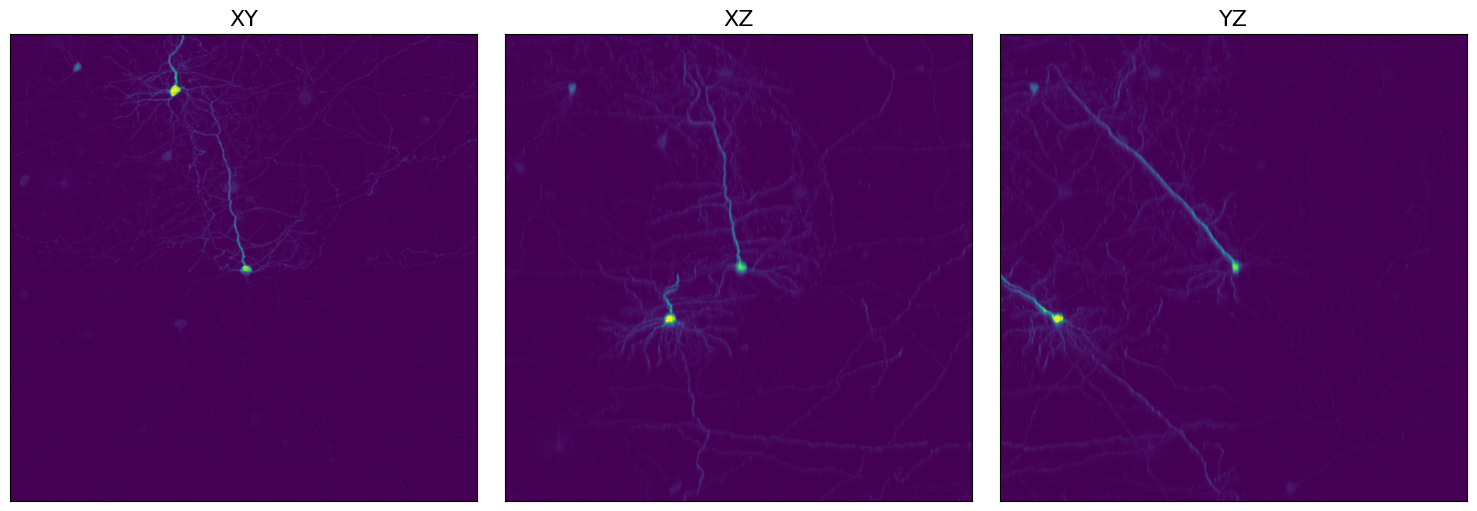

In [14]:
# Region of interest
origin = [19870.244, 7980.912, 4308.1934]
shape = [512, 512, 512]
from_center = True

# Read img
voxel = img_util.to_voxels(origin, downsample_factor=downsample_factor)
img_chunk = read_from_s3(img, voxel, shape, from_center=from_center)

# Plot mips
plot_mips(img_chunk, clip_bool=True)


In [16]:
np.histogram(img_chunk.flatten())

(array([134211748,      3272,      1105,       521,       382,       323,
              210,        96,        43,        28]),
 array([   46. ,  1576.6,  3107.2,  4637.8,  6168.4,  7699. ,  9229.6,
        10760.2, 12290.8, 13821.4, 15352. ]))

In [17]:
from cupyx.scipy.ndimage import gaussian_laplace

log_img = gaussian_laplace(img_chunk, 2)

ModuleNotFoundError: No module named 'cupyx'

## Sampling Patches

In [ ]:
# Set threshold
percentile = 80
p_threshold = np.percentile(img_chunk, percentile)
print("p_threshold:", p_threshold)

In [ ]:
from numpy.random import randint as rand


def sample_chunk_from_large_arr(arr, shape):
    cnt = 0
    while cnt < 25:
        start_idxs = [rand(0, s1 - s2) for s1, s2 in zip(arr.shape, shape)]
        slices = [slice(idx, idx + cs) for idx, cs in zip(start_idxs, shape)]
        brightness_score = np.sum(arr[tuple(slices)] > p_threshold)
        if brightness_score >  30 ** 3:
            print("scores:", brightness_score, brightness_score - 30 ** 3)
            print("# attempts:", cnt)
            return arr[tuple(slices)]
        else:
            cnt += 1
    print("Fail: Sampling Chunk")
    return arr[tuple(slices)]


def sample_projection(arr, axis):
    cnt = 0
    n_slices = np.random.randint(5, 15)
    while cnt < 25:
        start = np.random.randint(0, 108 - n_slices)
        projection = compute_slice_projection(arr, start, n_slices, axis)
        if np.sum(projection > 0.7) > 0:
            print("# Slices:", n_slices)
            return projection
        else:
            cnt += 1
    print("Fail: Sampling Slices")
    return projection


def compute_slice_projection(arr, start, n_slices, axis):
    end = start + n_slices
    if axis == 0:
        return np.max(arr[start:end, :, :], axis=axis)
    elif axis == 1:
        return np.max(arr[:, start:end, :], axis=axis)
    elif axis == 2:
        return np.max(arr[:, :, start:end], axis=axis)
    else:
        print("Axis must be 0, 1, or 2")


In [ ]:
sampled_chunk = sample_chunk_from_large_arr(img_chunk, (108, 108, 108))
plot_mips(sampled_chunk, clip_bool=False)

In [ ]:
projection = sample_projection(sampled_chunk, 0)
plt.imshow(projection)